Antes de executar, abrir a aba Arquivos e carregar
os arquivos .csv dentro de uma pasta "data"

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import duckdb
from pathlib import Path

def load_csv_tables() -> None:
    for file in Path("/content/data/").glob("*.csv"):
        table_name = file.stem
        duckdb.register(table_name, pd.read_csv(file))
        duckdb.execute(f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM {table_name}")

tables = load_csv_tables()

# Caso o seguinte erro apareça: ImportError: generic_type: type "ExplainType" is already registered!
# Pressione Ctrl+M . (ou Runtime -> Restart Session)

In [5]:
# View para adicionar colunas de data à tabela de pedidos
# Remove pedidos antes de 2017 e de setembro de 2018 pela
# quantidade pequena de entradas
duckdb.sql("""
  CREATE OR REPLACE VIEW VW_ORDERS AS
  SELECT
    *,
    EXTRACT(MONTH FROM CAST(order_approved_at AS DATE)) AS approval_month,
    EXTRACT(YEAR FROM CAST(order_approved_at AS DATE)) AS approval_year,
    STRFTIME(CAST(order_approved_at AS DATE), '%Y-%m') AS approval_date,
    EXTRACT(MONTH FROM CAST(order_purchase_timestamp AS DATE)) AS purchase_month,
    EXTRACT(YEAR FROM CAST(order_purchase_timestamp AS DATE)) AS purchase_year,
    STRFTIME(CAST(order_purchase_timestamp AS DATE), '%Y-%m') AS purchase_date
  FROM orders
  WHERE 1=1
    AND approval_year >= 2017
    AND NOT (approval_year = 2018 AND approval_month = 9)
""")
duckdb.sql("SELECT * FROM VW_ORDERS LIMIT 5;")

┌──────────────────────────────────┬──────────────────────────────────┬──────────────┬──────────────────────────┬─────────────────────┬──────────────────────────────┬───────────────────────────────┬───────────────────────────────┬────────────────┬───────────────┬───────────────┬────────────────┬───────────────┬───────────────┐
│             order_id             │           customer_id            │ order_status │ order_purchase_timestamp │  order_approved_at  │ order_delivered_carrier_date │ order_delivered_customer_date │ order_estimated_delivery_date │ approval_month │ approval_year │ approval_date │ purchase_month │ purchase_year │ purchase_date │
│             varchar              │             varchar              │   varchar    │         varchar          │       varchar       │           varchar            │            varchar            │            varchar            │     int64      │     int64     │    varchar    │     int64      │     int64     │    varchar    │
├────────────

In [6]:
# Resumo por Vendedor (pedidos, receita, ticket médio, frete)
# Selecionando 10 maiores por receita
duckdb.sql("""
  SELECT
    sellers.seller_id "Vendedor",
    COUNT(VW_ORDERS.order_id) "Pedidos",
    ROUND(SUM(order_items.price),2) "Receita",
    ROUND(AVG(order_items.price),2) "Ticket Médio",
    ROUND(SUM(order_items.freight_value),2) "Frete"
  FROM
    VW_ORDERS
  INNER JOIN order_items ON VW_ORDERS.order_id = order_items.order_id
  INNER JOIN sellers ON order_items.seller_id = sellers.seller_id
  INNER JOIN customers ON customers.customer_id = VW_ORDERS.customer_id
  GROUP BY "Vendedor"
  ORDER BY Receita DESC
  LIMIT 10
""")

┌──────────────────────────────────┬─────────┬───────────┬──────────────┬──────────┐
│             Vendedor             │ Pedidos │  Receita  │ Ticket Médio │  Frete   │
│             varchar              │  int64  │  double   │    double    │  double  │
├──────────────────────────────────┼─────────┼───────────┼──────────────┼──────────┤
│ 4869f7a5dfa277a7dca6462dcf3b52b2 │    1156 │ 229472.63 │       198.51 │ 20168.07 │
│ 53243585a1d6dc2643021fd1853d8905 │     410 │ 222776.05 │       543.36 │ 13080.63 │
│ 4a3ca9315b744ce9f8e9374361493884 │    1987 │ 200472.92 │       100.89 │ 35067.04 │
│ fa1c13f2614d7b5c4749cbc52fecda94 │     586 │ 194042.03 │       331.13 │  10042.7 │
│ 7c67e1448b00f6e969d365cea6b010ab │    1364 │ 187923.89 │       137.77 │ 51612.55 │
│ 7e93a43ef30c4f03f38b393420bc753a │     339 │ 175032.87 │       516.32 │  6297.63 │
│ da8622b14eb17ae2831f4ac5b9dab84a │    1551 │ 160236.57 │       103.31 │ 24955.75 │
│ 7a67c85e85bb2ce8582c35f2203ad736 │    1168 │ 141505.56 │       

In [7]:
# Clientes por Vendedor (exploração)
duckdb.sql("""
  SELECT
    sellers.seller_id "Vendedor",
    count(VW_ORDERS.customer_id) "Número de Clientes"
  FROM VW_ORDERS
  INNER JOIN order_items ON VW_ORDERS.order_id = order_items.order_id
  INNER JOIN sellers ON order_items.seller_id = sellers.seller_id
  INNER JOIN customers ON customers.customer_id = VW_ORDERS.customer_id
  GROUP BY "Vendedor", customers.customer_id
  ORDER BY "Número de Clientes" DESC
""")

# Não parece haver uma concentração notável em vendedores específicos.
# Há muitos vendedores com vendas únicas.

┌──────────────────────────────────┬────────────────────┐
│             Vendedor             │ Número de Clientes │
│             varchar              │       int64        │
├──────────────────────────────────┼────────────────────┤
│ 2709af9587499e95e803a6498a5a56e9 │                 21 │
│ 8e6d7754bc7e0f22c96d255ebda59eba │                 20 │
│ ce27a3cc3c8cc1ea79d11e561e9bebb6 │                 20 │
│ f326006815956455b2859abd58fe7e39 │                 15 │
│ 0b36063d5818f81ccb94b54adfaebbf5 │                 15 │
│ 1f50f920176fa81dab994f9023523100 │                 14 │
│ e7d5b006eb624f13074497221eb37807 │                 14 │
│ e7d5b006eb624f13074497221eb37807 │                 13 │
│ 98dac6635aee4995d501a3972e047414 │                 12 │
│ 98dac6635aee4995d501a3972e047414 │                 12 │
│                ·                 │                  · │
│                ·                 │                  · │
│                ·                 │                  · │
│ 406822777a0b

In [8]:
# Pedidos e Receita por Vendedor (por período, top 10)
a = duckdb.sql("""
  SELECT
    order_items.seller_id "Vendedor",
    VW_ORDERS.approval_date "Data",
    COUNT(order_items.seller_id) "Pedidos",
    ROUND(SUM(price),2) "Receita"
  FROM order_items
  INNER JOIN VW_ORDERS ON VW_ORDERS.order_id = order_items.order_id
  INNER JOIN customers ON customers.customer_id = VW_ORDERS.customer_id
  WHERE
    order_status IN ('delivered','shipped')
    AND order_items.seller_id IN (
      '4869f7a5dfa277a7dca6462dcf3b52b2', '53243585a1d6dc2643021fd1853d8905',
      '4a3ca9315b744ce9f8e9374361493884', 'fa1c13f2614d7b5c4749cbc52fecda94',
      '7c67e1448b00f6e969d365cea6b010ab', '7e93a43ef30c4f03f38b393420bc753a',
      'da8622b14eb17ae2831f4ac5b9dab84a', '7a67c85e85bb2ce8582c35f2203ad736',
      '1025f0e2d44d7041d6cf58b6550e0bfa', '955fee9216a65b617aa5c0531780ce60'
    )
  GROUP BY "Vendedor", "Data"
  ORDER BY "Vendedor", "Data"
""")
a

┌──────────────────────────────────┬─────────┬─────────┬──────────┐
│             Vendedor             │  Data   │ Pedidos │ Receita  │
│             varchar              │ varchar │  int64  │  double  │
├──────────────────────────────────┼─────────┼─────────┼──────────┤
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2017-07 │      12 │   1300.2 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2017-08 │      44 │   3864.2 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2017-09 │      82 │   7505.6 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2017-10 │      71 │   6325.6 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2017-11 │     173 │ 13203.64 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2017-12 │      29 │   1572.6 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2018-01 │      82 │   8808.7 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2018-02 │      43 │   4006.8 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2018-03 │     149 │ 12803.67 │
│ 1025f0e2d44d7041d6cf58b6550e0bfa │ 2018-04 │     136 │ 14549.65 │
│                ·                 │    ·    │  

In [9]:
# Receita Total por Status
b = duckdb.sql("""
  SELECT
    VW_ORDERS.order_status "Status",
    ROUND(SUM(order_items.price),2) "Receita Total"
  FROM VW_ORDERS
  INNER JOIN order_items ON order_items.order_id = VW_ORDERS.order_id
  GROUP BY "Status"
  ORDER BY "Receita Total"
""").df()
b

,Status,Receita Total
0,approved,209.60
1,invoiced,58615.74
2,processing,60077.22
3,canceled,92183.10
4,shipped,149599.99
5,delivered,13179356.70


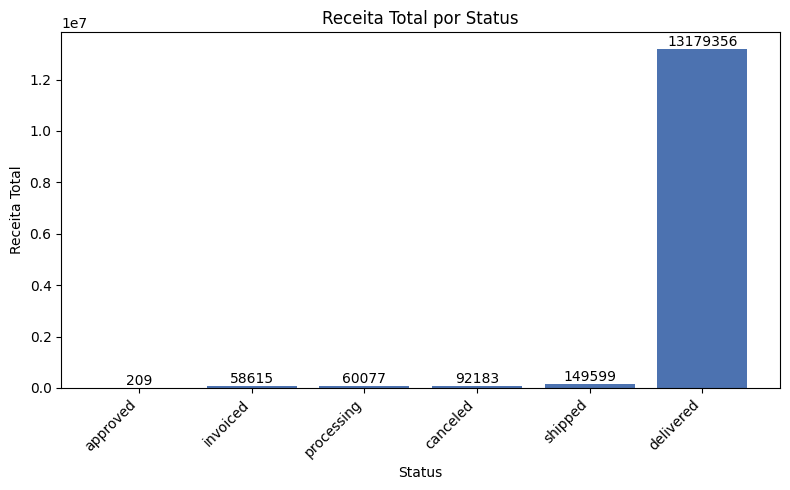

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(b["Status"], b["Receita Total"], color="#4C72B0")
ax.bar_label(bars, fmt='%d')
ax.set_xlabel("Status")
ax.set_ylabel("Receita Total")
ax.set_title("Receita Total por Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# A absoluta maioria da receita no dataset corresponde aos pedidos marcados como
# "entregue", havendo poucos cancelados

In [ ]:
# Pedidos por Status
c = duckdb.sql("""
  SELECT
    DISTINCT order_status "Status",
    COUNT(*) "Pedidos",
  FROM VW_ORDERS
  GROUP BY "Status"
  ORDER BY "Pedidos"
""").df()
c

,Status,Pedidos
0,approved,2
1,invoiced,296
2,processing,299
3,canceled,464
4,unavailable,603
5,shipped,1097
6,delivered,96197


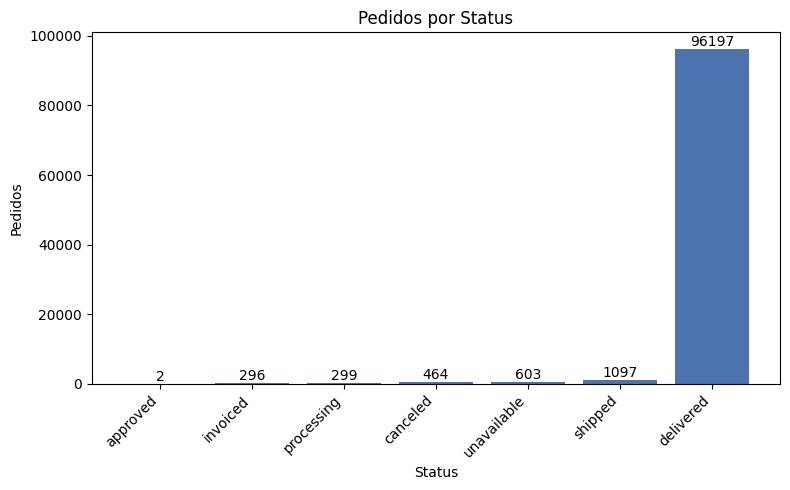

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(c["Status"], c["Pedidos"], color="#4C72B0")
ax.bar_label(bars)
ax.set_xlabel("Status")
ax.set_ylabel("Pedidos")
ax.set_title("Pedidos por Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# A absoluta maioria dos pedidos no dataset também corresponde aos pedidos
# marcados como "entregue"

In [ ]:
# Ticket Médio por Categoria de Produto
d = duckdb.sql("""
  SELECT
    CASE WHEN products.product_category_name IS NULL
      THEN 'outros'
      ELSE products.product_category_name
    END "Categoria de Produto",
    ROUND(AVG(order_items.price),2) "Ticket Médio"
  FROM VW_ORDERS
  INNER JOIN order_items ON order_items.order_id = VW_ORDERS.order_id
  INNER JOIN products on products.product_id = order_items.product_id
  WHERE order_status IN ('delivered','shipped')
  GROUP BY "Categoria de Produto"
  ORDER BY "Ticket Médio" DESC
""").df()
d

,Categoria de Produto,Ticket Médio
0,pcs,1095.61
1,portateis_casa_forno_e_cafe,631.45
2,eletrodomesticos_2,470.85
3,agro_industria_e_comercio,343.65
4,instrumentos_musicais,282.94
...,...,...
69,alimentos_bebidas,55.53
70,cds_dvds_musicais,52.14
71,fraldas_higiene,37.94
72,flores,33.64


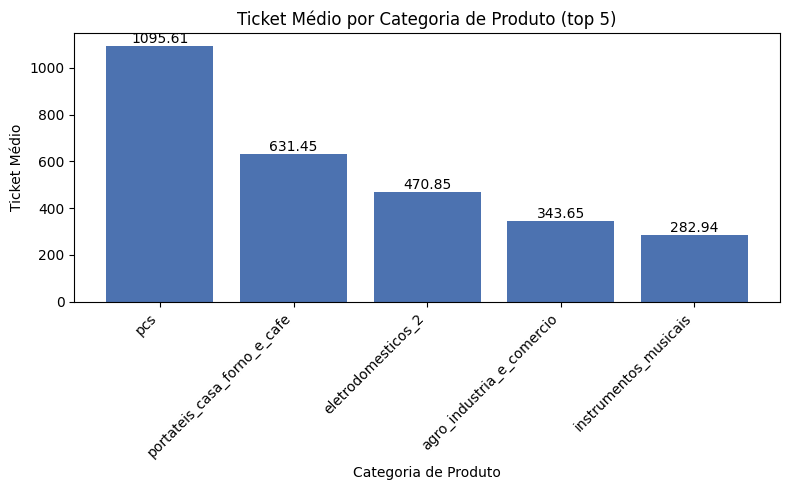

In [ ]:
# Ticket Médio por Categoria de Produto (top 5)
d_top = d.head(5)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(d_top["Categoria de Produto"], d_top["Ticket Médio"], color="#4C72B0")
ax.bar_label(bars)
ax.set_xlabel("Categoria de Produto")
ax.set_ylabel("Ticket Médio")
ax.set_title("Ticket Médio por Categoria de Produto (top 5)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

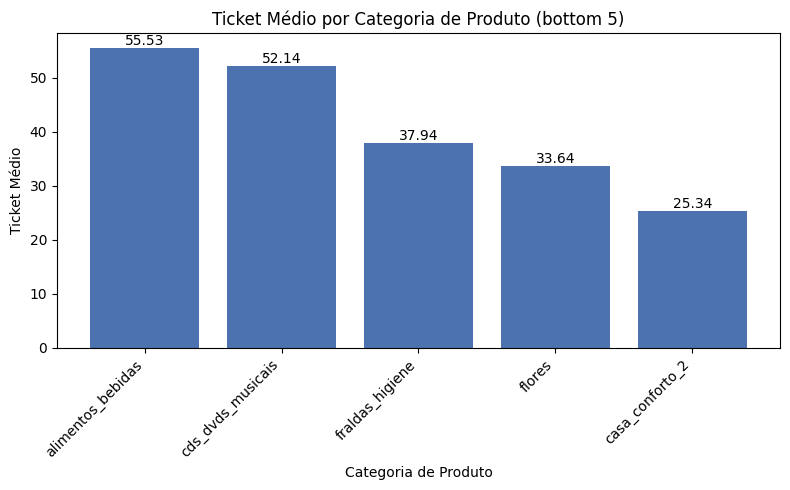

In [ ]:
# Ticket Médio por Categoria de Produto (bottom 5)
d_bot = d.tail(5)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(d_bot["Categoria de Produto"], d_bot["Ticket Médio"], color="#4C72B0")
ax.bar_label(bars)
ax.set_xlabel("Categoria de Produto")
ax.set_ylabel("Ticket Médio")
ax.set_title("Ticket Médio por Categoria de Produto (bottom 5)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# A diferença absoluta entre os maiores e menores tickets médios é bastante
# notória, mas vale notar que a quantidade é bastante reduzida nos itens de TM
# mais alto, como visto em análise posterior

In [ ]:
# Ticket Médio por Categoria de Produto (por período)
# Mapeando categorias vazias como "Outros"
e = duckdb.sql("""
  SELECT
    CASE WHEN products.product_category_name IS NULL
      THEN 'outros'
      ELSE products.product_category_name
    END "Categoria de Produto",
    approval_date "Data",
    ROUND(AVG(order_items.price),2) "Ticket Médio",
    COUNT(order_items.order_id) "Pedidos"
  FROM VW_ORDERS
  INNER JOIN order_items ON order_items.order_id = VW_ORDERS.order_id
  INNER JOIN products on products.product_id = order_items.product_id
  WHERE order_status IN ('delivered','shipped')
  GROUP BY "Categoria de Produto", "Data"
  ORDER BY "Categoria de Produto", "Data"
""").df()
e

,Categoria de Produto,Data,Ticket Médio,Pedidos
0,agro_industria_e_comercio,2017-01,21.99,3
1,agro_industria_e_comercio,2017-02,32.12,7
2,agro_industria_e_comercio,2017-03,41.00,2
3,agro_industria_e_comercio,2017-05,394.99,4
4,agro_industria_e_comercio,2017-06,1390.00,1
...,...,...,...,...
1234,utilidades_domesticas,2018-04,94.86,466
1235,utilidades_domesticas,2018-05,102.70,629
1236,utilidades_domesticas,2018-06,96.57,578
1237,utilidades_domesticas,2018-07,105.09,548


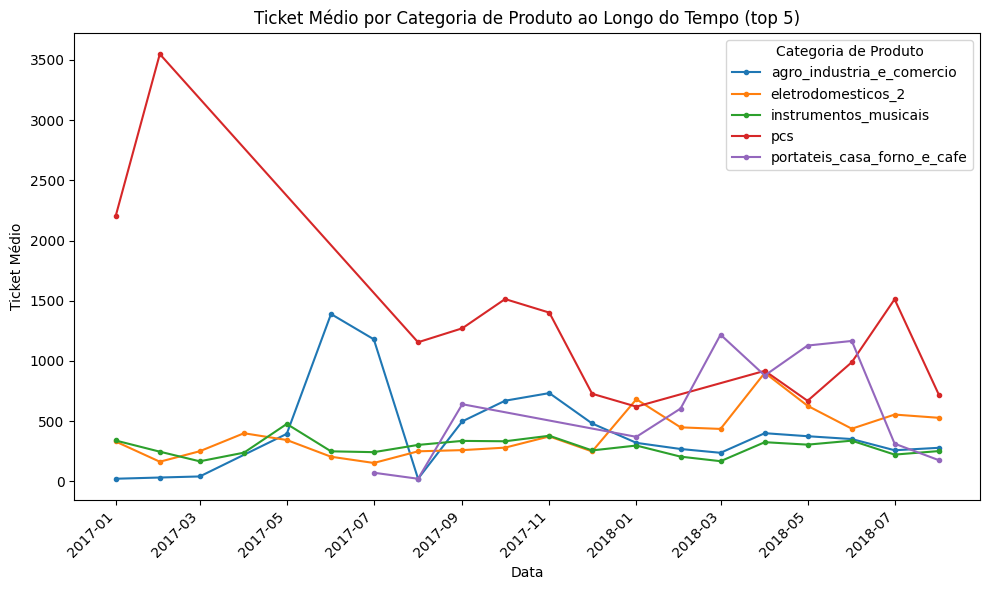

In [ ]:
# Ticket Médio por Categoria de Produto (por período; top 5)
top_categorias = ["pcs","portateis_casa_forno_e_cafe","eletrodomesticos_2","agro_industria_e_comercio","instrumentos_musicais"]
e_top = e[e["Categoria de Produto"].isin(top_categorias)].copy()
e_top["Data"] = pd.to_datetime(e_top["Data"])

fig, ax = plt.subplots(figsize=(10, 6))

for categoria, grupo in e_top.groupby("Categoria de Produto"):
    ax.plot(grupo["Data"], grupo["Ticket Médio"], marker="o", markersize=3, label=categoria)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_xlabel("Data")
ax.set_ylabel("Ticket Médio")
ax.set_title("Ticket Médio por Categoria de Produto ao Longo do Tempo (top 5)")
ax.legend(title="Categoria de Produto")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

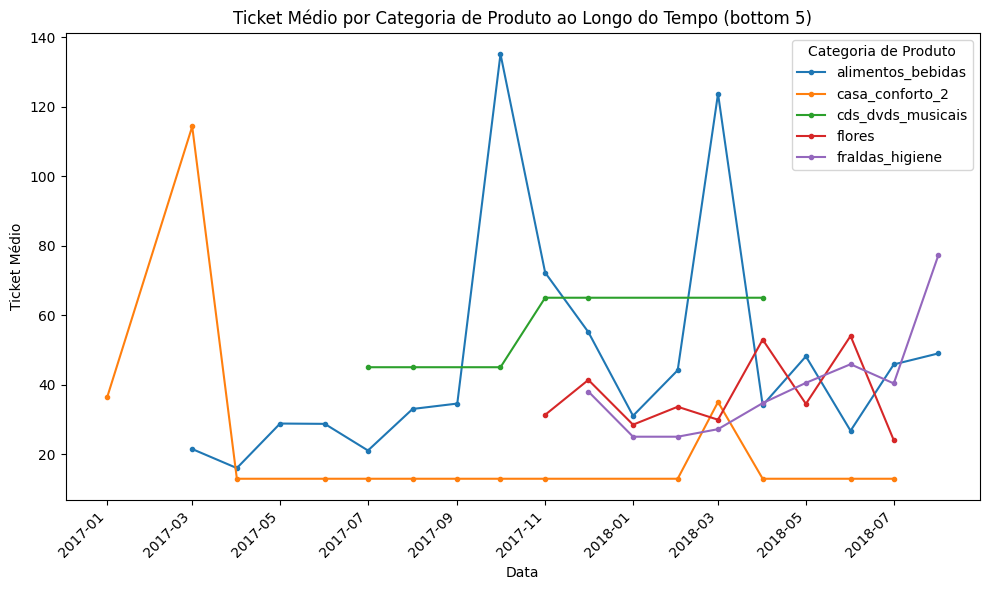

In [ ]:
# Ticket Médio por Categoria de Produto (por período; bottom 5)
bot_categorias = ["alimentos_bebidas", "cds_dvds_musicais", "fraldas_higiene", "flores", "casa_conforto_2"]
e_bot = e[e["Categoria de Produto"].isin(bot_categorias)].copy()
e_bot["Data"] = pd.to_datetime(e_bot["Data"])

fig, ax = plt.subplots(figsize=(10, 6))

for categoria, grupo in e_bot.groupby("Categoria de Produto"):
    ax.plot(grupo["Data"], grupo["Ticket Médio"], marker="o", markersize=3, label=categoria)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_xlabel("Data")
ax.set_ylabel("Ticket Médio")
ax.set_title("Ticket Médio por Categoria de Produto ao Longo do Tempo (bottom 5)")
ax.legend(title="Categoria de Produto")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Nas análises ao longo do tempo, faltam dados para avaliar consistentemente a
# evolução do ticket médio de cada categoria, havendo muita flutuação e meses
# sem compras em algumas categorias

In [ ]:
# Itens por Categoria de Produto
f = duckdb.sql("""
  SELECT
    CASE WHEN products.product_category_name IS NULL
      THEN 'outros'
      ELSE products.product_category_name
    END "Categoria de Produto",
    COUNT(order_items.order_id) "Unidades Compradas"
  FROM order_items
  INNER JOIN products on products.product_id = order_items.product_id
  INNER JOIN VW_ORDERS on VW_ORDERS.order_id = order_items.order_id
  WHERE VW_ORDERS.order_status IN ('delivered','shipped')
  GROUP BY "Categoria de Produto"
  ORDER BY "Unidades Compradas" DESC
""").df()
f

,Categoria de Produto,Unidades Compradas
0,cama_mesa_banho,11063
1,beleza_saude,9537
2,esporte_lazer,8515
3,moveis_decoracao,8174
4,informatica_acessorios,7713
...,...,...
69,portateis_cozinha_e_preparadores_de_alimentos,14
70,cds_dvds_musicais,14
71,pc_gamer,8
72,fashion_roupa_infanto_juvenil,7


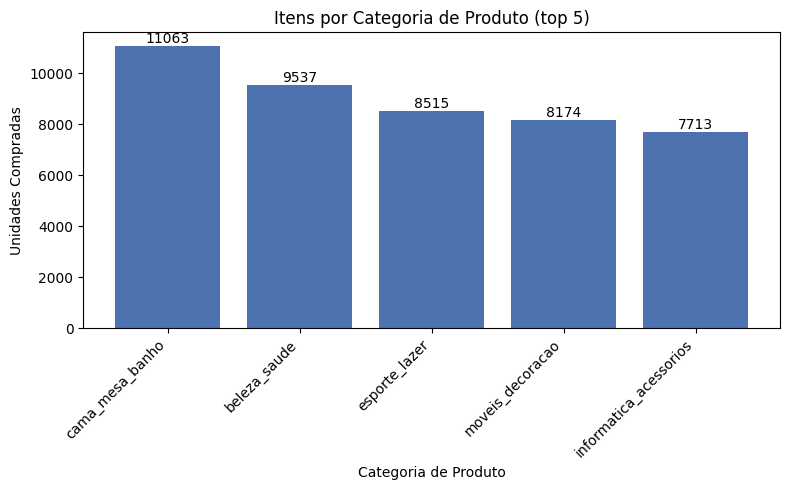

In [ ]:
# Itens por Categoria de Produto (top 5)
f_top = f.head(5)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(f_top["Categoria de Produto"], f_top["Unidades Compradas"], color="#4C72B0")
ax.bar_label(bars)
ax.set_xlabel("Categoria de Produto")
ax.set_ylabel("Unidades Compradas")
ax.set_title("Itens por Categoria de Produto (top 5)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

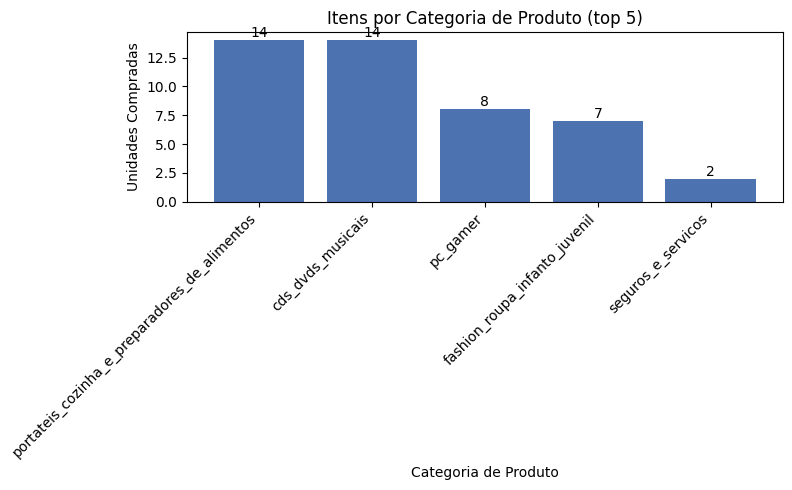

In [ ]:
# Itens por Categoria de Produto (top 5)
f_bot = f.tail(5)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(f_bot["Categoria de Produto"], f_bot["Unidades Compradas"], color="#4C72B0")
ax.bar_label(bars)
ax.set_xlabel("Categoria de Produto")
ax.set_ylabel("Unidades Compradas")
ax.set_title("Itens por Categoria de Produto (top 5)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Pesquisa por produtos comprados em conjunto,
# excluindo itens da mesma categoria
duckdb.sql("""
  SELECT
    p1.product_category_name AS categoria_1,
    p2.product_category_name AS categoria_2,
    COUNT(DISTINCT a.order_id) AS "Pedidos Relacionados"
  FROM order_items a
  INNER JOIN order_items b ON a.order_id = b.order_id AND a.product_id < b.product_id
  INNER JOIN products p1 ON a.product_id = p1.product_id
  INNER JOIN products p2 ON b.product_id = p2.product_id
  WHERE 1=1
    AND p1.product_category_name IS NOT NULL
    AND p2.product_category_name IS NOT NULL
    AND p1.product_category_name <> 'NaN'
    AND p2.product_category_name <> 'NaN'
    AND p1.product_category_name <> p2.product_category_name
  GROUP BY categoria_1, categoria_2
  ORDER BY "Pedidos Relacionados" DESC
""")

┌───────────────────────┬────────────────────────────────────────────────┬──────────────────────┐
│      categoria_1      │                  categoria_2                   │ Pedidos Relacionados │
│        varchar        │                    varchar                     │        int64         │
├───────────────────────┼────────────────────────────────────────────────┼──────────────────────┤
│ cama_mesa_banho       │ moveis_decoracao                               │                   39 │
│ casa_conforto         │ cama_mesa_banho                                │                   39 │
│ moveis_decoracao      │ cama_mesa_banho                                │                   36 │
│ bebes                 │ brinquedos                                     │                   18 │
│ utilidades_domesticas │ moveis_decoracao                               │                   14 │
│ utilidades_domesticas │ cama_mesa_banho                                │                   13 │
│ bebes             

In [ ]:
# Pedidos por Categoria de Produto
duckdb.sql("""
  SELECT
    CASE WHEN products.product_category_name IS NULL
      THEN 'outros'
      ELSE products.product_category_name
    END "Categoria",
    COUNT(order_items.order_id) "Pedidos"
  FROM order_items
  INNER JOIN products on products.product_id = order_items.product_id
  GROUP BY "Categoria"
  ORDER BY "Pedidos" DESC
""")

┌───────────────────────────────────────────────┬─────────┐
│                   Categoria                   │ Pedidos │
│                    varchar                    │  int64  │
├───────────────────────────────────────────────┼─────────┤
│ cama_mesa_banho                               │   11115 │
│ beleza_saude                                  │    9670 │
│ esporte_lazer                                 │    8641 │
│ moveis_decoracao                              │    8334 │
│ informatica_acessorios                        │    7827 │
│ utilidades_domesticas                         │    6964 │
│ relogios_presentes                            │    5991 │
│ telefonia                                     │    4545 │
│ ferramentas_jardim                            │    4347 │
│ automotivo                                    │    4235 │
│   ·                                           │       · │
│   ·                                           │       · │
│   ·                                   